In [1]:
from scipy.stats import ttest_rel
import pickle
import matplotlib.pyplot as plt


#with open("goals.pkl", "rb") as f:
    #goals = pickle.load(f)

with open("times_a.pkl", "rb") as f:
    times_a = pickle.load(f)

with open("times_b.pkl", "rb") as f:
    times_b = pickle.load(f)
    
times_a_clean = []
times_b_clean = []

goals_a_reached = 0
goals_a_not_reached = 0
goals_b_reached = 0
goals_b_not_reached = 0

# Check to see if they dimensions coincide
assert len(times_a) == len(times_b), "Time lists do not match!"

# Cleaning the two arrays to analyze data (using only times when the goal is reached)
for i in range(len(times_a)):
    if times_a[i] != 0.0 and times_b[i] != 0.0:
        times_a_clean.append(times_a[i])
        times_b_clean.append(times_b[i])

    if times_a[i] != 0.0:
        goals_a_reached = goals_a_reached + 1
    else:
        goals_a_not_reached = goals_a_not_reached + 1

    if times_b[i] != 0.0:
        goals_b_reached = goals_b_reached + 1
    else:
        goals_b_not_reached = goals_b_not_reached + 1

In [2]:
# Calculating and display t-test for paired data (time stats)
t_stat, p_value = ttest_rel(times_a_clean, times_b_clean)

print("Result of the paired t-test:\n")
print(f"t-statistic: {t_stat}\n")
print(f"p-value: {p_value}\n")

Result of the paired t-test:

t-statistic: -0.904773466010379

p-value: 0.3692041547179964



In [3]:
# Analysis of the results (time stats)
alpha = 0.05
if p_value < alpha:
    print("Significant difference between the two algorithm!")
else:
    print("No significant difference between the two algorithm!")

No significant difference between the two algorithm!


In [4]:
import numpy as np

# Other possible statistics on time 
print("Mean time for A:", np.mean(times_a_clean))
print("Mean time for B:", np.mean(times_b_clean))

Mean time for A: 54.53891302718491
Mean time for B: 59.01610132514453


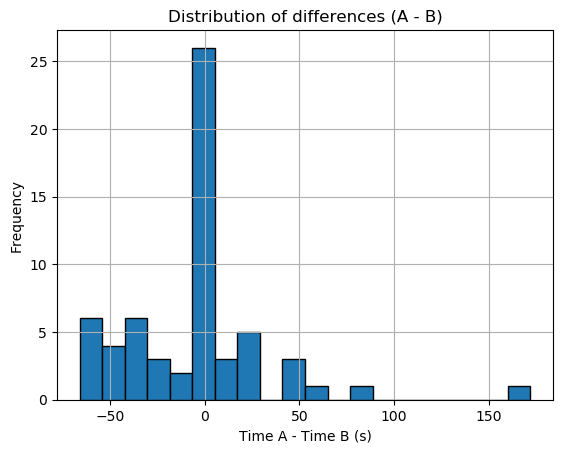

In [5]:
# Plotting the differences of times
diffs = [a - b for a, b in zip(times_a_clean, times_b_clean)]

plt.hist(diffs, bins=20, edgecolor='black')
plt.title("Distribution of differences (A - B)")
plt.xlabel("Time A - Time B (s)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

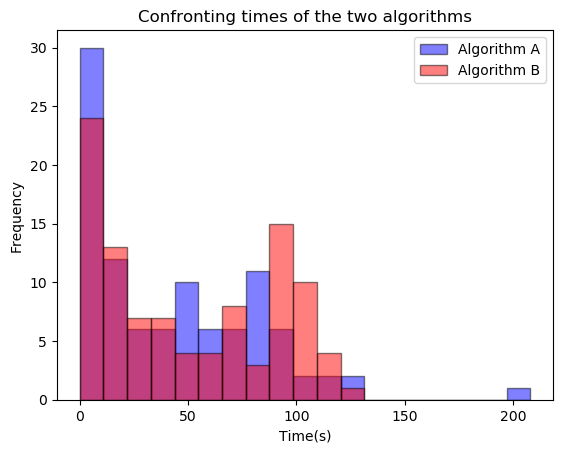

In [6]:
# Defining the bin for the histogram
bins = np.linspace(0, max(max(times_a), max(times_b)), 20)

plt.hist(times_a, bins=bins, alpha=0.5, label='Algorithm A', color='blue', edgecolor='black')
plt.hist(times_b, bins=bins, alpha=0.5, label='Algorithm B', color='red', edgecolor='black')

# Add lables and title
plt.xlabel('Time(s)')
plt.ylabel('Frequency')
plt.title('Confronting times of the two algorithms')
plt.legend(loc='upper right')
plt.show()